# Тестирование YOLOv10

## Загрузим и экспортируем модель YOLOv10n в формат OpenVINO

In [3]:
# Загружаем предобученную YOLOv10n и экспортируем её в OpenVINO
model = YOLO('yolov10n.pt')
model.export(format='openvino', imgsz=640)

core = ov.Core()
model_path = 'yolov10n_openvino_model/yolov10n.xml'
compiled_model = core.compile_model(model_path, 'CPU')
input_layer = compiled_model.input(0)
output_layer = compiled_model.output(0)

Ultralytics YOLOv8.2.78  Python-3.12.2 torch-2.4.0+cpu CPU (AMD Ryzen 7 5700X 8-Core Processor)
YOLOv10n summary (fused): 285 layers, 2,762,608 parameters, 0 gradients, 8.6 GFLOPs

PyTorch: starting from 'yolov10n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.6 MB)

OpenVINO: starting export with openvino 2024.6.0-17404-4c0f47d2335-releases/2024/6...
OpenVINO: export success  3.3s, saved as 'yolov10n_openvino_model\' (9.2 MB)

Export complete (5.5s)
Results saved to B:\Python projects\inno\Methodology\Methodology_Article
Predict:         yolo predict task=detect model=yolov10n_openvino_model imgsz=640  
Validate:        yolo val task=detect model=yolov10n_openvino_model imgsz=640 data=None  
Visualize:       https://netron.app


## Подготовим функции (Препроцессинг и Постпроцессинг v10)

In [4]:
def preprocess(frame, input_size=640):
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    scale = min(input_size / w, input_size / h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (new_w, new_h))
    canvas = np.full((input_size, input_size, 3), 114, dtype=np.uint8)
    canvas[:new_h, :new_w] = resized
    input_tensor = canvas.transpose(2, 0, 1).astype(np.float32) / 255.0
    input_tensor = input_tensor[None, ...]
    return input_tensor, scale, (w, h)

In [5]:
def postprocess(output, conf_threshold=0.5, original_shape=(640, 480)):
    predictions = output[0]
    boxes = []
    person_detected = False
    
    for pred in predictions:
        score = pred[4]
        if score < conf_threshold:
            continue
            
        class_id = int(pred[5])
        if class_id == 0:  # Класс "person"
            person_detected = True
            x1 = pred[0] / 640 * original_shape[0]
            y1 = pred[1] / 640 * original_shape[1]
            x2 = pred[2] / 640 * original_shape[0]
            y2 = pred[3] / 640 * original_shape[1]
            boxes.append([x1, y1, x2, y2, score, class_id])
            
    return boxes, person_detected

## Загрузка видео

In [6]:
def upload_single_video(video_path):
    cap = cv2.VideoCapture(video_path)
    fps_video = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    print(f"Видео: {video_path}, FPS: {fps_video}, всего кадров: {total_frames}")
    return total_frames

upload_single_video('videos/backlight.mp4')
upload_single_video('videos/fulllight.mp4')
upload_single_video('videos/lowlight.mp4')

Видео: videos/backlight.mp4, FPS: 24.0, всего кадров: 1097
Видео: videos/fulllight.mp4, FPS: 24.0, всего кадров: 1070
Видео: videos/lowlight.mp4, FPS: 24.0, всего кадров: 1071


1071

## Обработка видео

In [7]:
def processing_video(video_path):
    cap = cv2.VideoCapture(video_path)
    fps_video = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Обработка видео: {video_path}, FPS: {fps_video}, всего кадров: {total_frames}")

    results = []
    loss_counter = 0
    loss_series = []

    with tqdm(total=total_frames, desc="Обработка кадров") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            start_time = time.perf_counter()

            input_tensor, scale, orig_size = preprocess(frame)
            result = compiled_model([input_tensor])[output_layer]
            boxes, person_now = postprocess(result, original_shape=orig_size)

            end_time = time.perf_counter()
            inference_time = end_time - start_time

            # Логика TTL
            if not person_now:
                loss_counter += 1
            else:
                if loss_counter > 0:
                    loss_series.append(loss_counter)
                    loss_counter = 0

            results.append({
                'frame': int(cap.get(cv2.CAP_PROP_POS_FRAMES)),
                'time_sec': cap.get(cv2.CAP_PROP_POS_MSEC) / 1000,
                'inference_time': inference_time,
                'person_detected': int(person_now),
                'num_detections': len(boxes),
            })
            pbar.update(1)

    cap.release()
    return results, loss_series

results_backlight, loss_backlight = processing_video('videos/backlight.mp4')
results_fulllight, loss_fulllight = processing_video('videos/fulllight.mp4')
results_lowlight, loss_lowlight = processing_video('videos/lowlight.mp4')

Обработка видео: videos/backlight.mp4, FPS: 24.0, всего кадров: 1097


Обработка кадров:   0%|          | 0/1097 [00:00<?, ?it/s]

Обработка видео: videos/fulllight.mp4, FPS: 24.0, всего кадров: 1070


Обработка кадров:   0%|          | 0/1070 [00:00<?, ?it/s]

Обработка видео: videos/lowlight.mp4, FPS: 24.0, всего кадров: 1071


Обработка кадров:   0%|          | 0/1071 [00:00<?, ?it/s]

## Результаты производительности

In [9]:
def average_FPS_graph(results, name):
    df = pd.DataFrame(results)
    df['fps'] = 1 / df['inference_time']
    df['fps_smooth'] = df['fps'].rolling(window=10).mean()
    
    plt.figure(figsize=(12,5))
    plt.plot(df['time_sec'], df['fps'], alpha=0.3, label='FPS (сырой)')
    plt.plot(df['time_sec'], df['fps_smooth'], 'r-', label='FPS (сглаженный)')
    plt.xlabel('Время (с)')
    plt.ylabel('FPS')
    plt.title(f'YOLOv10: Производительность инференса для {name}')
    plt.legend()
    plt.grid(True)
    plt.show()

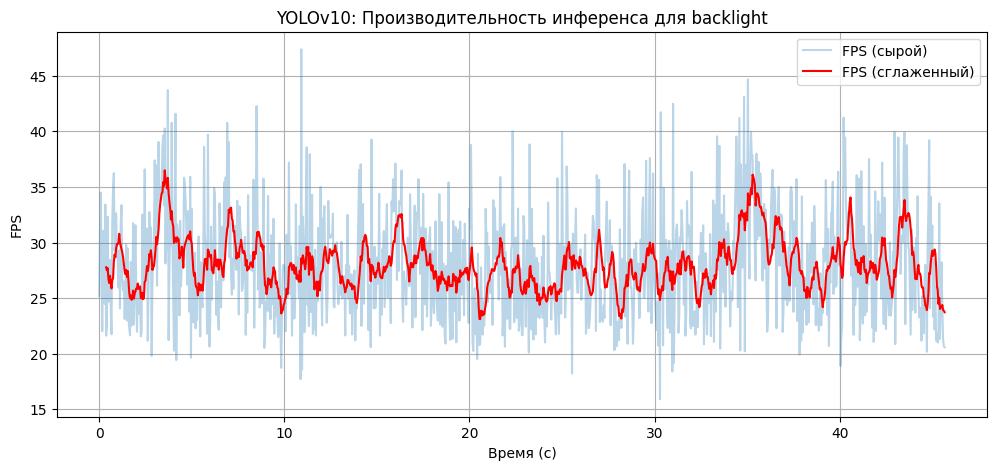

In [10]:
average_FPS_graph(results_backlight, "backlight")

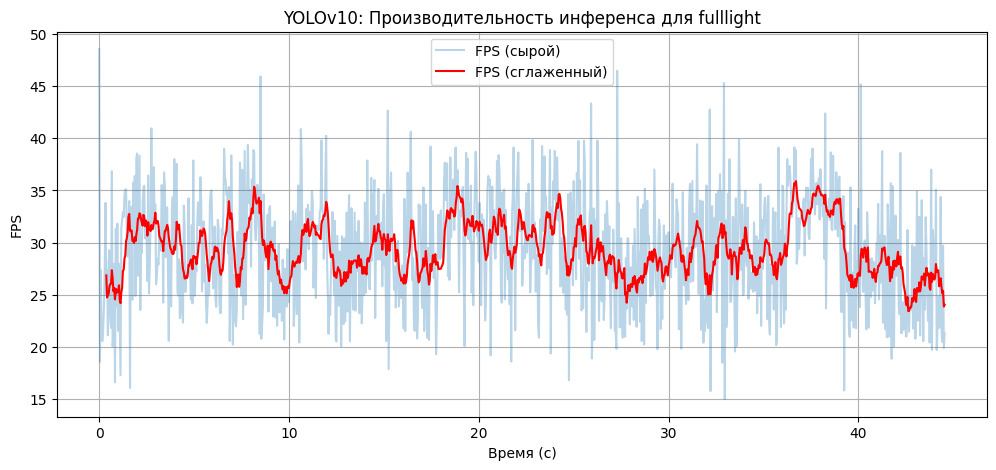

In [11]:
average_FPS_graph(results_fulllight, "fulllight")

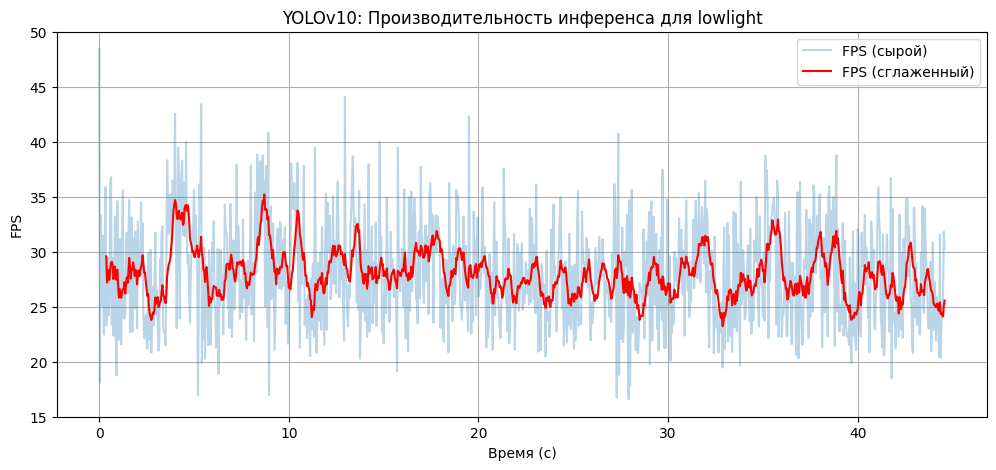

In [12]:
average_FPS_graph(results_lowlight, "lowlight")

## Результаты присутствие человека

In [13]:
def show_person_presence(results, loss_series, name):
    df = pd.DataFrame(results)

    plt.figure(figsize=(12,3))
    plt.fill_between(df['frame'], 0, df['person_detected'], color='green', alpha=0.5, label='Человек в кадре')
    plt.xlabel('Номер кадра')
    plt.ylabel('Детекция')
    plt.yticks([0,1], ['нет','да'])
    plt.title(f'Присутствие человека в кадре на видео {name}.mp4')
    plt.legend()
    plt.grid(True)
    plt.savefig('presence_plot_frames.png')
    plt.show()

    if loss_series:
        loss_series = np.array(loss_series)
        print(f"Серий потери цели: {len(loss_series)}")
        print(f"Средняя длина серии (кадров): {loss_series.mean():.2f}")
        print(f"Максимальная длина серии (кадров): {loss_series.max()}")
        print(f"Медианная длина серии (кадров): {np.median(loss_series):.2f}")
    
        plt.figure(figsize=(10,5))
        plt.hist(loss_series, bins=30, alpha=0.7, edgecolor='black')
        plt.xlabel('Длительность потери (кадров)')
        plt.ylabel('Частота')
        plt.title('Распределение длительностей потери цели (TTL)')
        plt.grid(True)
        plt.savefig('ttl_hist.png')
        plt.show()
    else:
        print("Потерь цели для не было.")

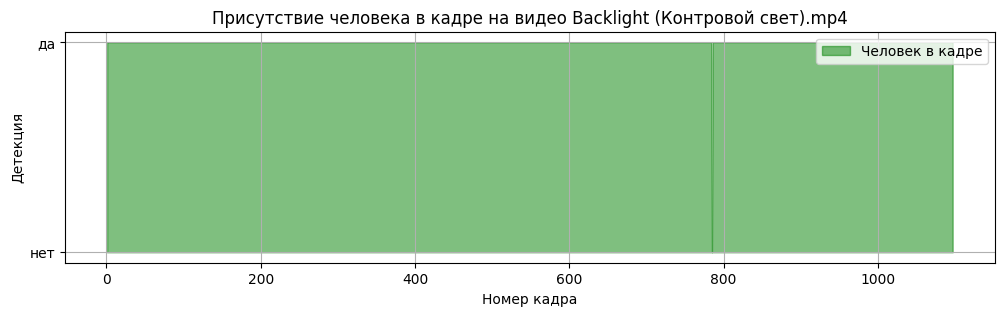

Серий потери цели: 1
Средняя длина серии (кадров): 1.00
Максимальная длина серии (кадров): 1
Медианная длина серии (кадров): 1.00


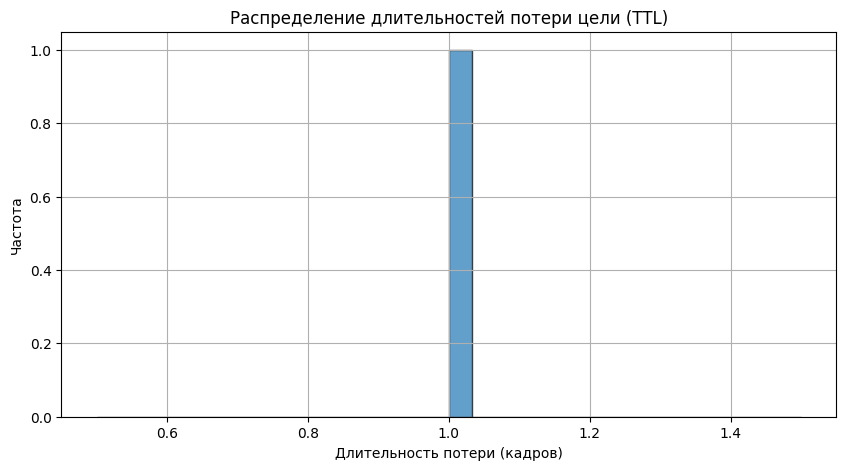

In [14]:
show_person_presence(results_backlight, loss_backlight, "Backlight (Контровой свет)")

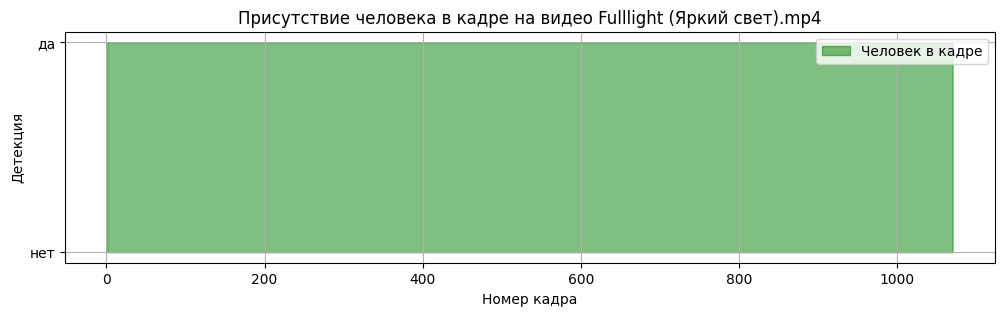

Потерь цели для не было.


In [15]:
show_person_presence(results_fulllight, loss_fulllight, "Fulllight (Яркий свет)")

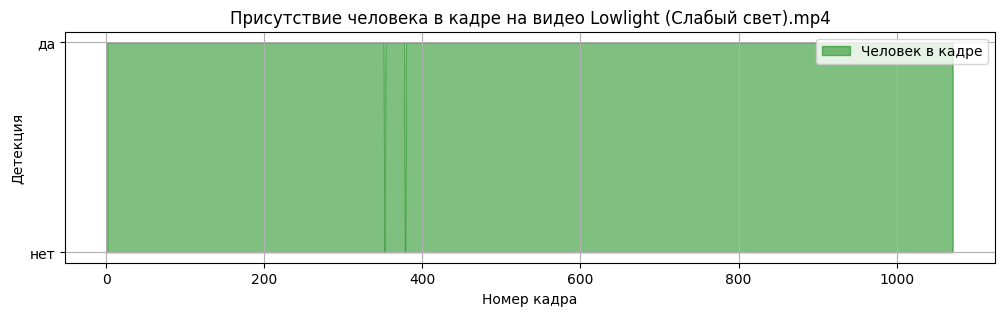

Серий потери цели: 2
Средняя длина серии (кадров): 1.00
Максимальная длина серии (кадров): 1
Медианная длина серии (кадров): 1.00


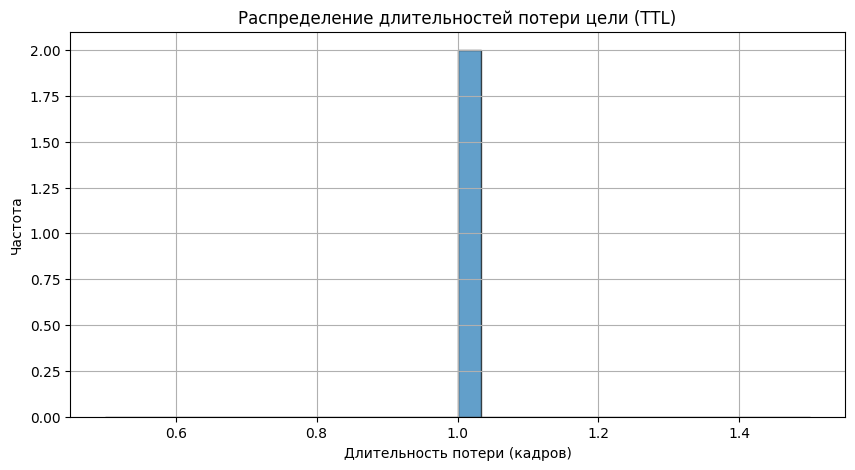

In [16]:
show_person_presence(results_lowlight, loss_lowlight, "Lowlight (Слабый свет)")